In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
df = pd.read_csv('../data/sales_data.csv')

In [5]:
df

,OrderID,Product,Quantity,Price,OrderDate
0,101,iPhone 15,1.0,1000.0,2026-01-15
1,102,AirPods Pro,2.0,250.0,2026-01-16
2,103,MacBook Air,1.0,1200.0,2026-02-01
3,104,iPhone 15,NaN,1000.0,02/18/2026
4,105,AirPods Pro,1.0,250.0,2026-02-20
5,106,Samsung S24,2.0,900.0,2026-03-05
6,107,MacBook Air,1.0,1200.0,NaN
7,108,iPhone 15,3.0,1000.0,2026-03-12


In [6]:
df.info();

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   OrderID    8 non-null      int64  
 1   Product    8 non-null      str    
 2   Quantity   7 non-null      float64
 3   Price      8 non-null      float64
 4   OrderDate  7 non-null      str    
dtypes: float64(2), int64(1), str(2)
memory usage: 452.0 bytes


In [7]:
df['Quantity']=df['Quantity'].fillna(1)

In [8]:
df['Quantity'] = df['Quantity'].astype(int)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   OrderID    8 non-null      int64  
 1   Product    8 non-null      str    
 2   Quantity   8 non-null      int64  
 3   Price      8 non-null      float64
 4   OrderDate  7 non-null      str    
dtypes: float64(1), int64(2), str(2)
memory usage: 452.0 bytes


In [10]:
df = df.dropna(subset=['OrderDate'])

In [11]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

In [12]:
df['TotalSales'] = df['Quantity'] * df['Price']

In [13]:
df

,OrderID,Product,Quantity,Price,OrderDate,TotalSales
0,101,iPhone 15,1,1000.0,2026-01-15,1000.0
1,102,AirPods Pro,2,250.0,2026-01-16,500.0
2,103,MacBook Air,1,1200.0,2026-02-01,1200.0
3,104,iPhone 15,1,1000.0,NaT,1000.0
4,105,AirPods Pro,1,250.0,2026-02-20,250.0
5,106,Samsung S24,2,900.0,2026-03-05,1800.0
7,108,iPhone 15,3,1000.0,2026-03-12,3000.0


In [14]:
product_sales =df.groupby('Product')['TotalSales'].sum().reset_index()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10004\2200268041.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalSales', y='Product', data=product_sales, palette='Blues_r')


<Axes: xlabel='TotalSales', ylabel='Product'>

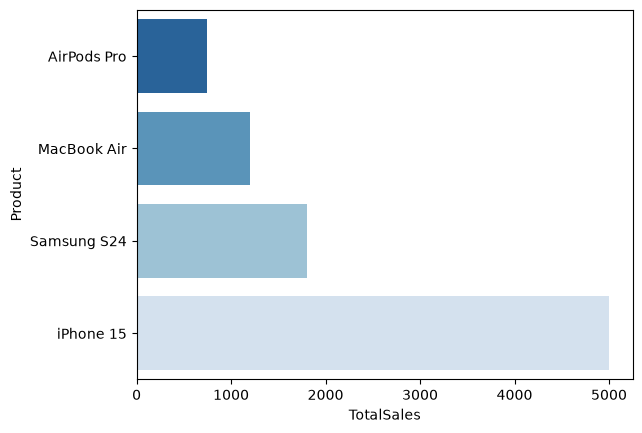

In [16]:
sns.barplot(x='TotalSales', y='Product', data=product_sales, palette='Blues_r')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10004\3616671245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalSales', y='Product', data=product_sales, palette='PuRd_r')


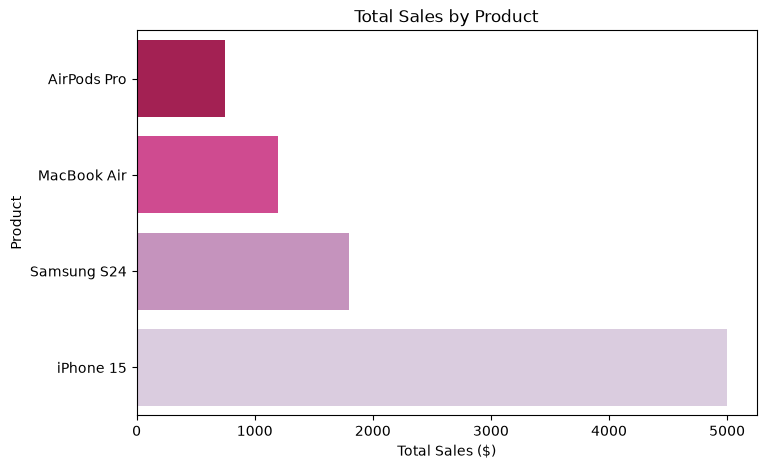

In [24]:
product_sales = df.groupby('Product')['TotalSales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='TotalSales', y='Product', data=product_sales, palette='PuRd_r')
plt.title('Total Sales by Product')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.show()